<a href="https://colab.research.google.com/github/Selvapriya05/Selvapriya-Codeboosters-2026/blob/main/Day_9/Day_9_AIAgents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install groq -q
print("Libraries installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 4.3 MB/s eta 0:00:00
Libraries installed successfully


In [7]:
#import all libraries

import sqlite3
import pandas as pd

import os

from groq import Groq

import re
print("All libraries imported successfully")

All libraries imported successfully


In [8]:
#Set your Groq API Key

import os
os.environ["GROQ_API_KEY"] = "GROQ_API_KEY"
client = Groq(api_key=os.environ["GROQ_API_KEY"])

MODEL = "llama-3.1-8b-instant"
print("Groq client initialized successfully")
print(f"Using model: {MODEL}")

Groq client initialized successfully
Using model: llama-3.1-8b-instant


In [10]:
import io
df = pd.read_csv("/content/student_performance.csv")
df.head(5)

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [11]:
#Create a SQLite database

conn = sqlite3.connect("college.db")

df.to_sql("students", conn, if_exists="replace", index=False)

print("Database created :college.db")
print("Table 'students' created with 30 student records")

test_df = pd.read_sql_query("SELECT COUNT(*) as total_rows FROM students", conn)
print(f"Verification: {test_df['total_rows'][0]} rows in database")

Database created :college.db
Table 'students' created with 30 student records
Verification: 30 rows in database


In [12]:
#Function to get the database schema (table structure)

def get_schema(conn, table_name="students"):
    """
    This function reads the structure of a database table.
    It returns information about each columns: name and database

    Parameters:
       conn: The SQLite connection object
    """

    cursor = conn.cursor()
    #Cursor - it is like a pointer that moves through database
    cursor.execute(f"PRAGMA table_info({table_name})") # PRAGMA - special function in python
    # PRAGMA-> show the column
    columns = cursor.fetchall()
    schema_lines = [f"Table: {table_name}"]
    schema_lines.append("Columns:")

    for col in columns:
      schema_lines.append(f"   - {col[1]} ({col[2]})")

    cursor.execute(f"SELECT * FROM {table_name} LIMIT 3")
    sample_rows = cursor.fetchall()
    schema_lines.append("\nSample rows (first 3):")

    for rows in sample_rows:
        schema_lines.append(f"   {rows}")

    return "\n" .join(schema_lines)

schema = get_schema(conn)
print(schema)

Table: students
Columns:
   - student_id (INTEGER)
   - name (TEXT)
   - age (INTEGER)
   - gender (TEXT)
   - department (TEXT)
   - semester (INTEGER)
   - math_score (INTEGER)
   - science_score (INTEGER)
   - english_score (INTEGER)
   - programming_score (INTEGER)
   - attendance_percentage (INTEGER)
   - city (TEXT)
   - admission_year (INTEGER)

Sample rows (first 3):
   (1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023)
   (1002, 'Priya Patel', 20, 'Female', 'Computer Science', 2, 76, 82, 88, 79, 87, 'Ahmedabad', 2023)
   (1003, 'Rohit Verma', 19, 'Male', 'Electronics', 2, 65, 74, 61, 55, 78, 'Delhi', 2023)


In [13]:
#Function to generate SQL from a natural language question

def generate_sql(user_question, schema_text, client, model):
    """
    Sends the user's question and database schema to the
    The LLM generate a SQL query that answers the question

    Parameters:
       user_question: The question typed by the user
    """
    system_prompt = f"""You are an expert SQL assistant.
You are connected to a SQLite database with the following structure

{schema_text}

Rules you must follow:
1. Generate ONLY a valid SQLite SQL query.
2. Do not include any explanation or text — only the SQL query.
3. Do not use markdown code blocks. Return the raw SQL only.
4. The table name is: students
5. Only use column names that exist in the schema above.
6. Use single quotes for string values in WHERE clauses (example: WHERE subject = 'Programming').
7. If the user asks for top N, use ORDER BY marks DESC LIMIT N.
"""
#This is the system prompt - the set of instructions we give to the AI

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_question}
        ],
        temperature=0.0
    )

    sql_query = response.choices[0].message.content.strip()

    return sql_query

question = "Show me all female students"
print(f"Question: {question}")
print("\nGenerating SQL...")

sql = generate_sql(question, schema, client, MODEL)
print(f"Generated SQL: \n{sql}")

Question: Show me all female students

Generating SQL...
Generated SQL: 
SELECT * FROM students WHERE gender = 'Female'


Executing SQL: SELECT * FROM students WHERE gender = 'Female'

Query returned 15 rows:
    student_id            name  age  gender        department  semester  \
0         1002     Priya Patel   20  Female  Computer Science         2   
1         1004     Sneha Reddy   20  Female        Mechanical         2   
2         1006     Meera Joshi   20  Female       Electronics         2   
3         1008     Divya Singh   19  Female  Computer Science         2   
4         1010      Ananya Das   19  Female  Computer Science         2   
5         1012     Pooja Gupta   19  Female             Civil         2   
6         1014   Kavya Nambiar   20  Female        Mechanical         2   
7         1016    Ritu Agarwal   20  Female       Electronics         2   
8         1018  Swati Kulkarni   19  Female  Computer Science         2   
9         1020    Nisha Kapoor   19  Female  Computer Science         2   
10        1022     Tanvi Mehta   19  Female  Computer Science         2   
11        102

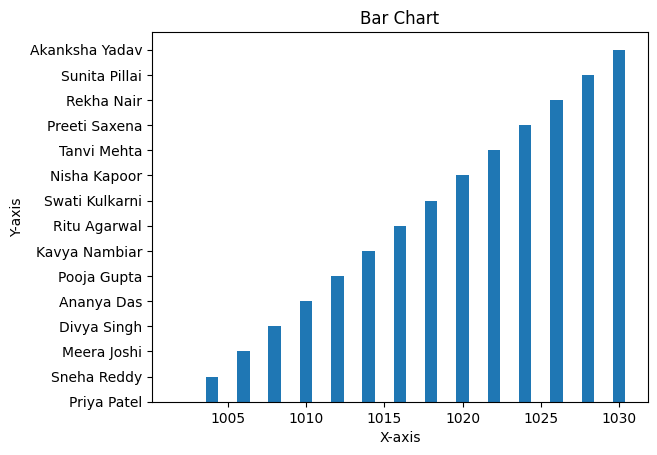

In [14]:
#Function to clean and execute the generated SQL query

def execute_sql(sql_query, conn):
   """
   This is for you
   """
   clean_sql = sql_query.strip()
   #strip - Remove whitespaces

   clean_sql = re.sub(r'sql\s*', '', clean_sql)
   clean_sql = clean_sql.strip()

   try:
       result_df = pd.read_sql_query(clean_sql, conn)
       return result_df, None
   except Exception as e:
       return None, str(e)

print(f"Executing SQL: {sql}")
result, error = execute_sql(sql, conn)

if error:
   print(f"Error: {error}")
else:
    print(f"\nQuery returned {len(result)} rows:")
    print(result)

#Matplotlib
import matplotlib.pyplot as plt
print(result)

x = result.iloc[:, 0]
y = result.iloc[:, 1]

plt.bar(x,y)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Bar Chart')
plt.show()


In [21]:
# The complete Text-to-SQL Agent function

def text_to_sql_agent(user_question, conn, client, model, verbose=True):
    """
    The main AI Agent function.
    Takes a user question in plain English and returns database results.

    This is the complete workflow:
    1.Get database schema
    2.Generate SQL using Groq LLM
    3.Execute SQL query on the database
    4.Return results
    """
    print(f"USER QUESTION: {user_question}")
    print("=" * 60)

    if verbose:
       print("\n[STEP 1] Reading database schema...")

    schema_text = get_schema(conn)

    if verbose:
       print("Schema loaded successfully")

    if verbose:
       print("\n[STEP 2] Generating SQL query with Groq LLM...")

    generated_sql = generate_sql(user_question, schema_text, client, model)

    if verbose:
       print("\n[STEP 3] Executing SQL on the database...")
    result_df, error = execute_sql(generated_sql, conn)


    if error:
       print(f"SQL Executing Error: {error}")
       return None, generated_sql

    if verbose:
       print(f"\n[STEP 4] Query Returned {len(result_df)} row(s)")
       print("\nRESULTS:")
       print("-" * 40)
       print(result_df.to_string(index=False))
    print("-" * 60)
    return result_df, generated_sql

result, sql_used = text_to_sql_agent(
    "Show top 5 students in Programming",
    conn, client, MODEL
)


USER QUESTION: Show top 5 students in Programming

[STEP 1] Reading database schema...
Schema loaded successfully

[STEP 2] Generating SQL query with Groq LLM...

[STEP 3] Executing SQL on the database...

[STEP 4] Query Returned 5 row(s)

RESULTS:
----------------------------------------
          name
    Ananya Das
   Tanvi Mehta
    Arjun Nair
Akanksha Yadav
   Divya Singh
------------------------------------------------------------
